### Package imports and read data

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
ps1_data = pd.read_pickle('datasets/ps1.pkl')

### Initial EDA

In [3]:
ps1_data.head()

,vx,vy,vz,R2,p
0,-0.129486,-0.378220,-1.303648,0.159817,1.462786
1,0.855369,0.378654,2.219246,0.875035,3.138316
2,-0.391171,0.782003,-1.747694,0.764544,0.564914
3,-0.533835,1.830559,-1.869053,3.635927,1.814512
4,-1.001277,-0.443638,-6.325631,1.199371,0.855995


In [4]:
ps1_data.shape

(5000, 5)

In [5]:
ps1_data.describe()

,vx,vy,vz,R2,p
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,0.001624,0.011467,0.012268,1.972555,0.991419
std,1.001303,0.984991,10.061490,2.207145,1.031325
min,-3.444211,-4.372958,-38.613684,0.000152,0.000083
25%,-0.663989,-0.668262,-6.716978,0.502088,0.273442
50%,0.004381,0.014887,0.096389,1.238110,0.664234
75%,0.662433,0.682803,6.698072,2.648618,1.352410
max,3.460661,3.270417,37.832599,28.426626,9.915629


In [6]:
ps1_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   vx      5000 non-null   float64
 1   vy      5000 non-null   float64
 2   vz      5000 non-null   float64
 3   R2      5000 non-null   float64
 4   p       5000 non-null   float64
dtypes: float64(5)
memory usage: 195.4 KB


### Distribution pair plot

#### Q1(a)
Make some pair plots of the distributions in the dataset and try to become a bit familiar with what the data might be showing.

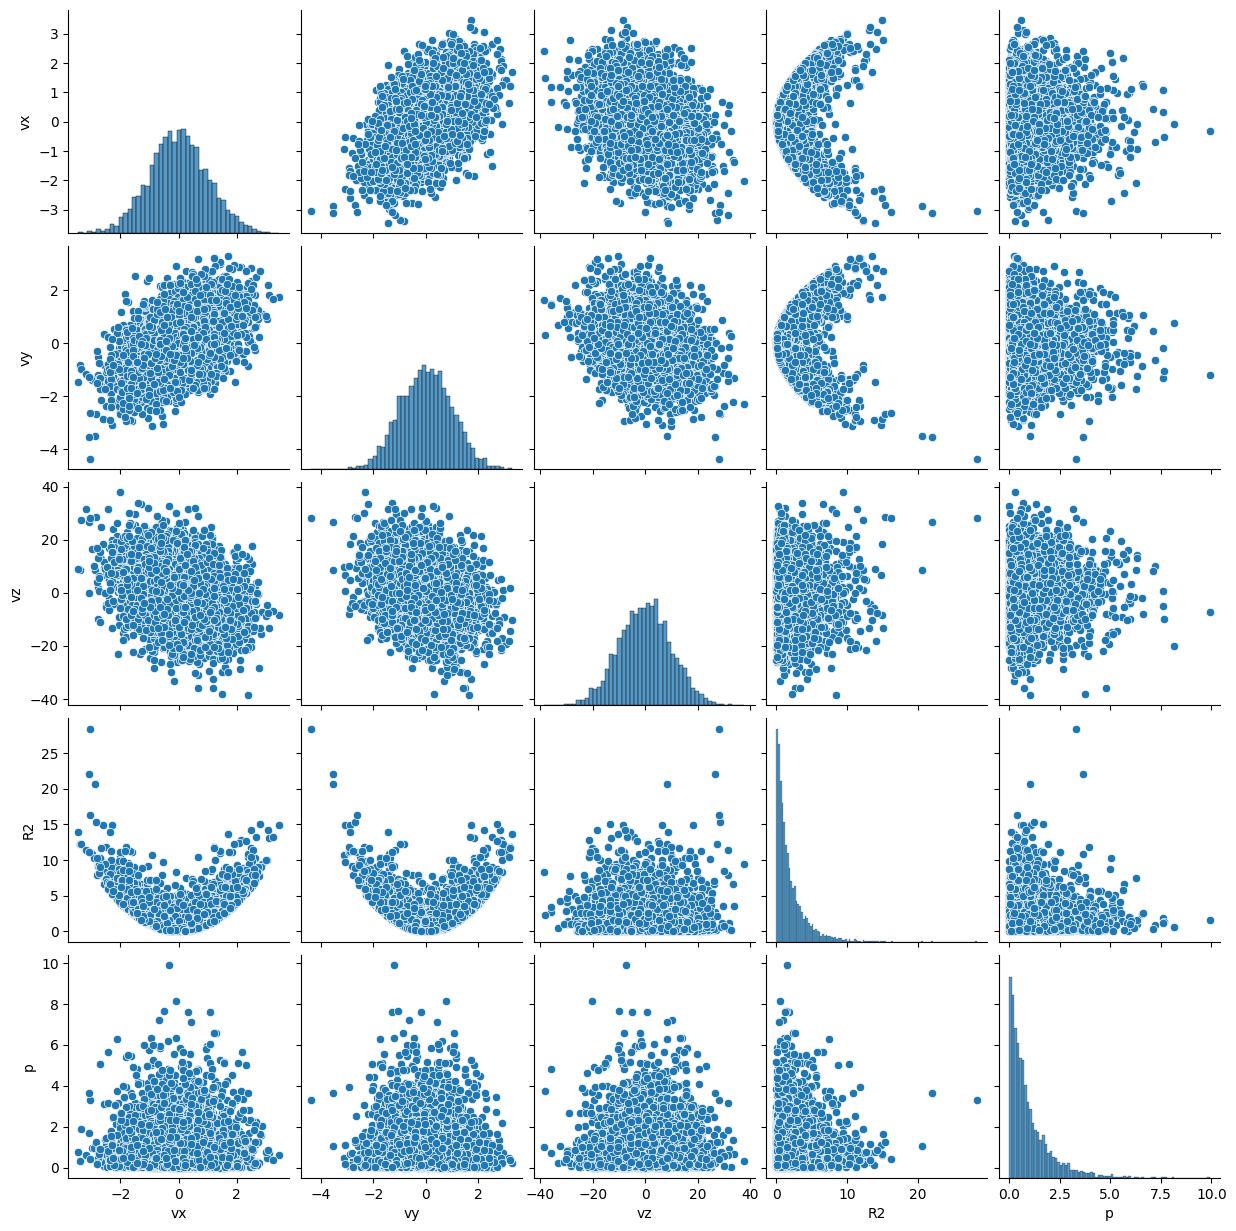

In [ ]:
import seaborn as sns
sns.pairplot(ps1_data)

#### Q1(b)
Make a publication quality plot which shows the two-dimensional distribution between the variables vx and vz.

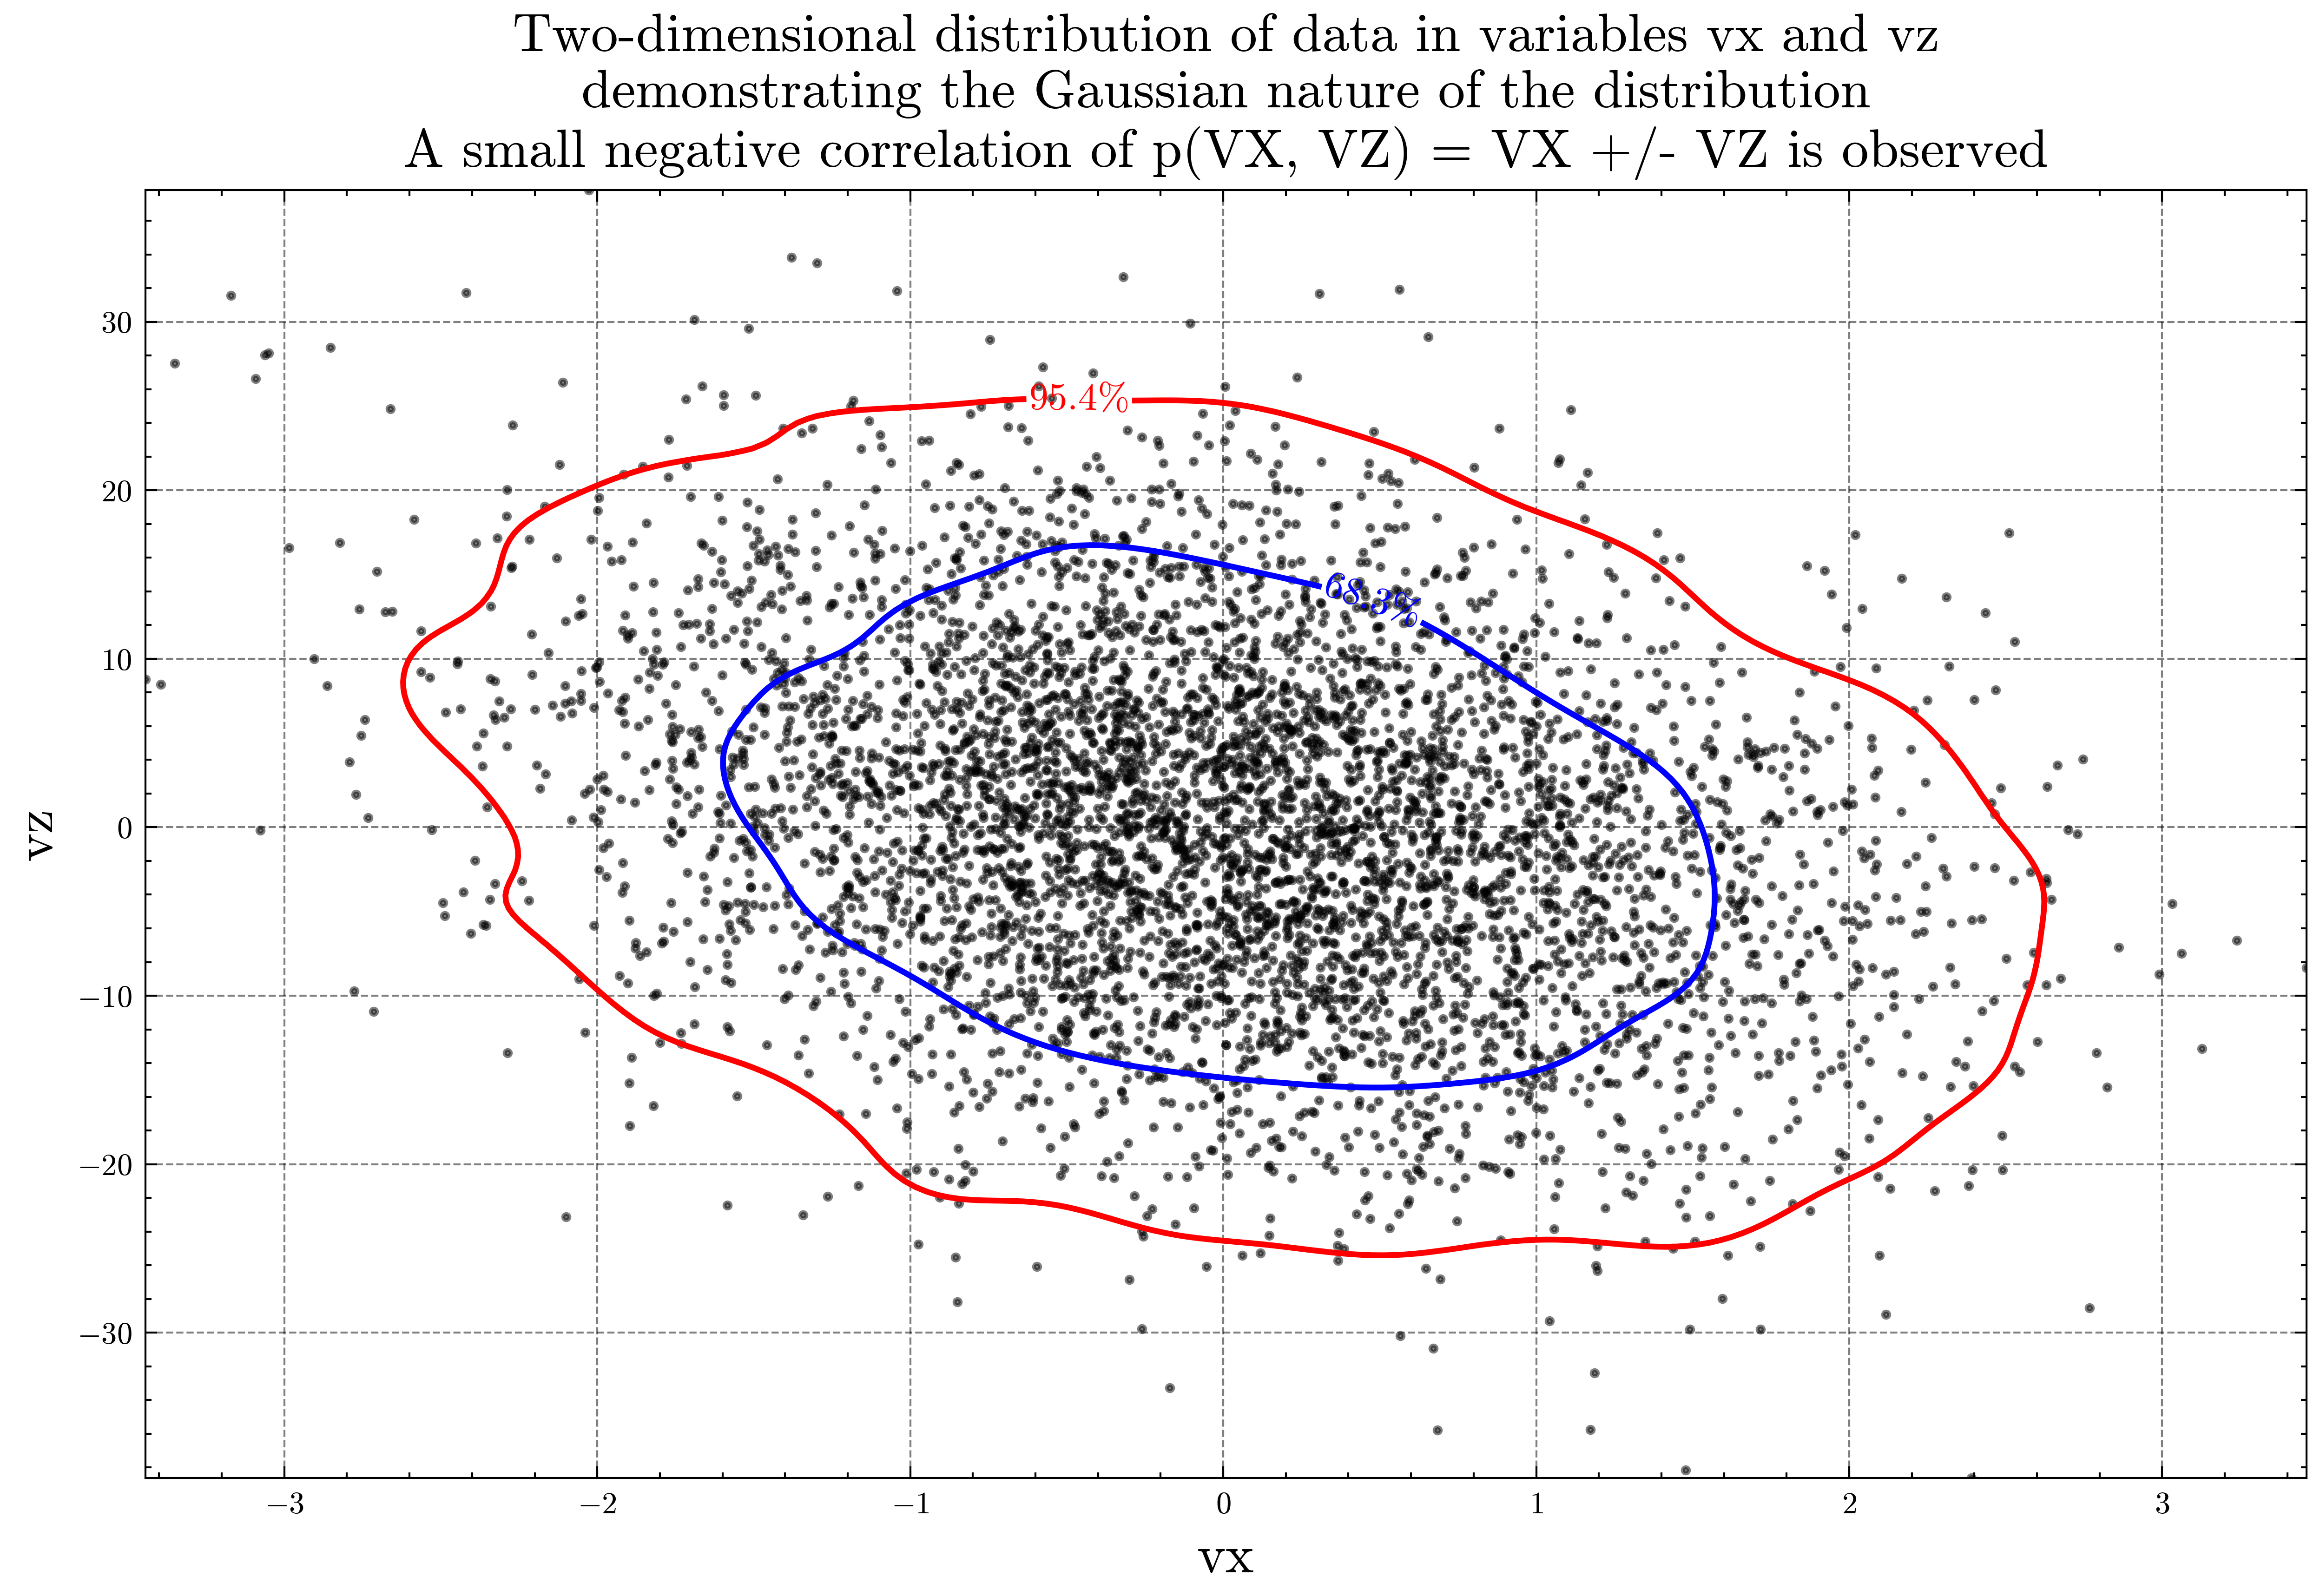

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde
import scienceplots

vx_vz = ps1_data[['vx', 'vz']]
x = vx_vz['vx'].values
y = vx_vz['vz'].values

# gaussian KDE
kde = gaussian_kde(np.vstack([x, y]))

# evaluate on a grid
xmin, xmax = x.min(), x.max()
ymin, ymax = y.min(), y.max()
X, Y = np.mgrid[xmin:xmax:200j, ymin:ymax:200j]
positions = np.vstack([X.ravel(), Y.ravel()])
Z = np.reshape(kde(positions).T, X.shape)

# Compute contour levels for 68.3% and 95.4%
Z_flat = Z.flatten()
Z_sorted = np.sort(Z_flat)
cdf = np.cumsum(Z_sorted)
cdf /= cdf[-1]
levels = []
for p in [1 - 0.954, 1 - 0.683]:
    idx = np.searchsorted(cdf, p)
    levels.append(Z_sorted[idx])

levels = np.sort(levels)
plt.style.use(['science', 'ieee', 'grid', 'no-latex'])
plt.figure(figsize=(10,6))
plt.scatter(x, y, marker='.', c='black', s=10, alpha=0.5)
contour = plt.contour(X, Y, Z, levels=levels, colors=['red', 'blue'], linewidths=1.5)
plt.clabel(contour, fmt={levels[0]: '95.4%', levels[1]: '68.3%'}, inline=True, fontsize=10)
plt.title('Two-dimensional distribution of data in variables vx and vz\ndemonstrating the Gaussian nature of the distribution\nA small negative correlation of p(VX, VZ) = VX +/- VZ is observed', fontsize=14)
plt.xlabel('vx', fontsize=14)
plt.ylabel('vz', fontsize=14)
plt.show()

#### 1(c)
Compute the correlation and covariance matrices between all variables in the dataset.

          vx        vy        vz        R2         p
vx  1.000000  0.499943 -0.283132  0.001504 -0.001291
vy  0.499943  1.000000 -0.274027 -0.001331 -0.024314
vz -0.283132 -0.274027  1.000000  0.008939  0.015736
R2  0.001504 -0.001331  0.008939  1.000000  0.002401
p  -0.001291 -0.024314  0.015736  0.002401  1.000000


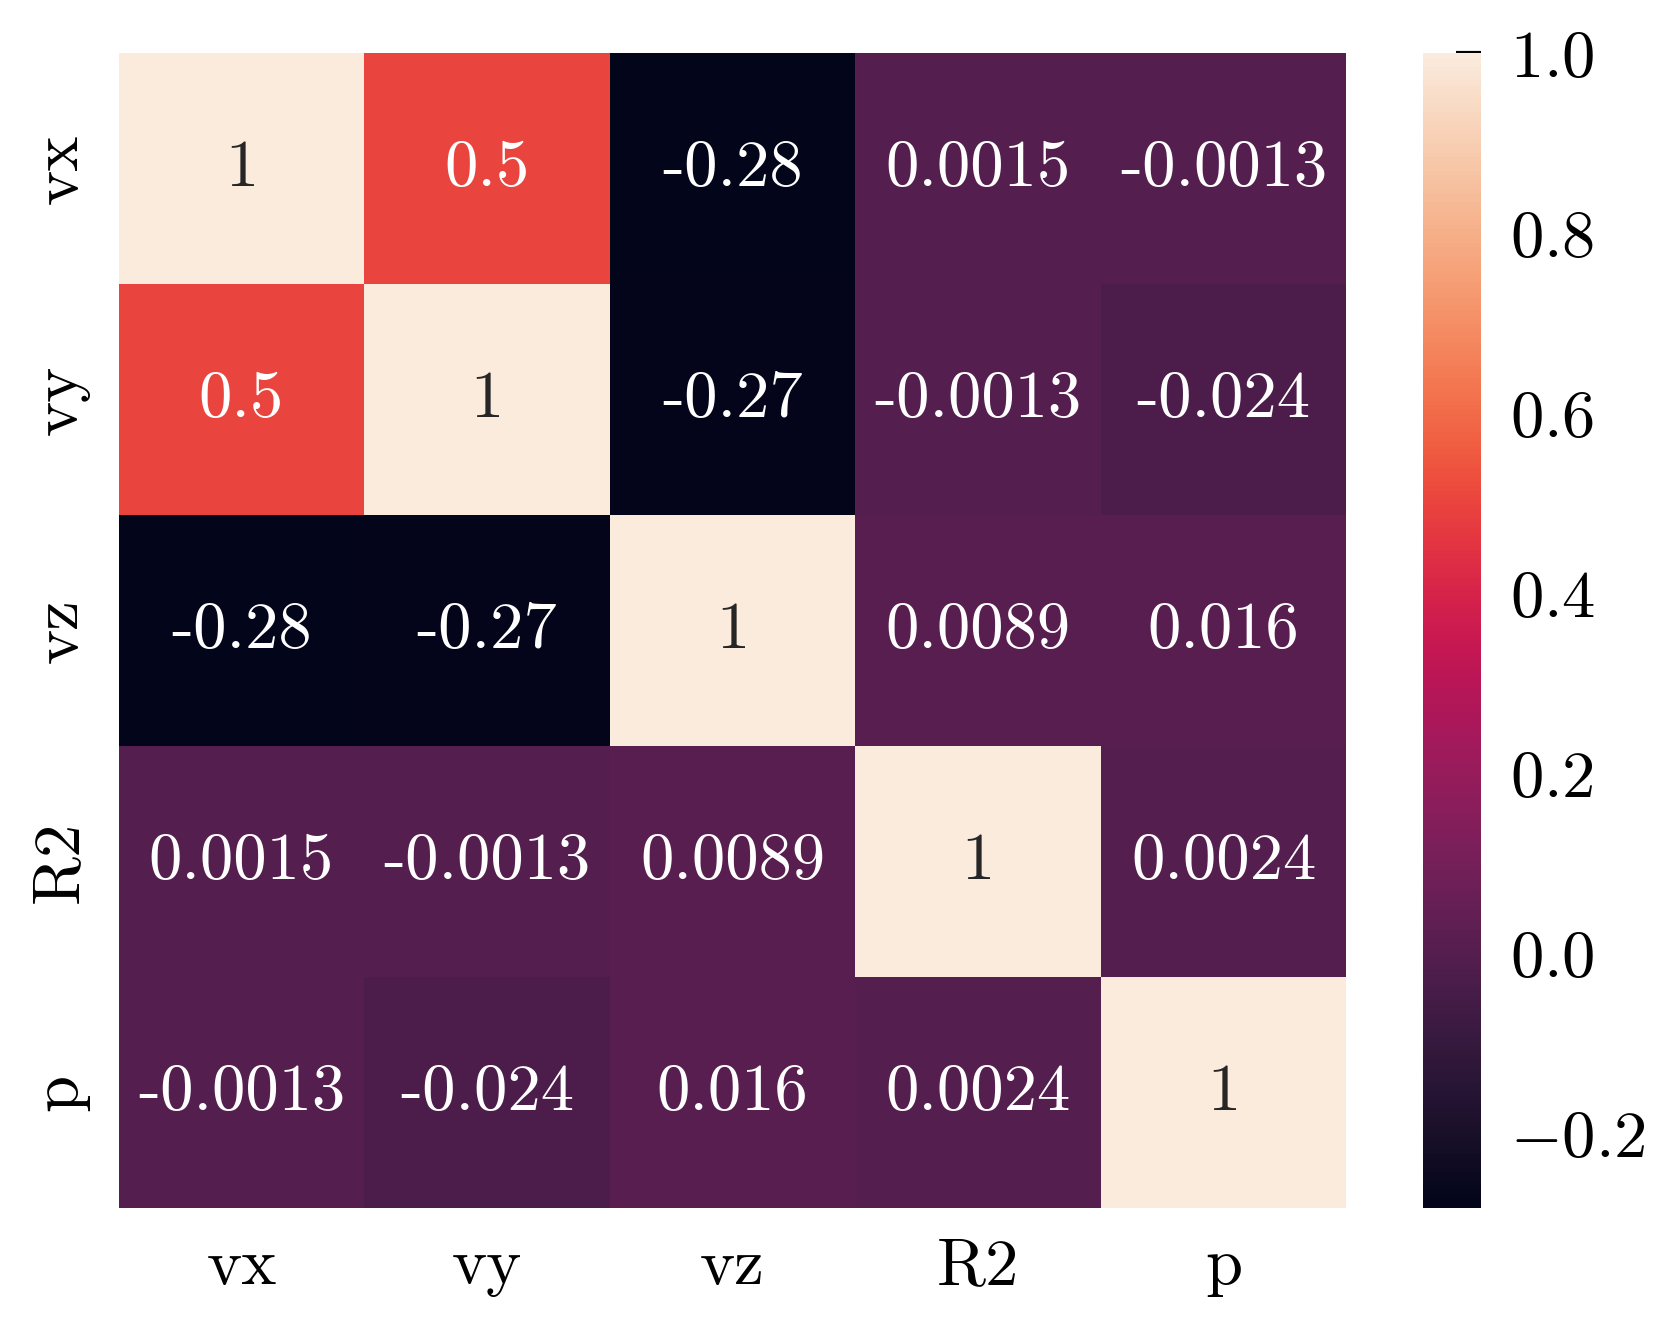

In [33]:
import seaborn as sns

print(ps1_data.corr())
sns.heatmap(ps1_data.corr(), annot=True)
plt.show()

          vx        vy          vz        R2         p
vx  1.002608  0.493081   -2.852446  0.003324 -0.001334
vy  0.493081  0.970208   -2.715740 -0.002893 -0.024699
vz -2.852446 -2.715740  101.233585  0.198513  0.163291
R2  0.003324 -0.002893    0.198513  4.871490  0.005466
p  -0.001334 -0.024699    0.163291  0.005466  1.063632


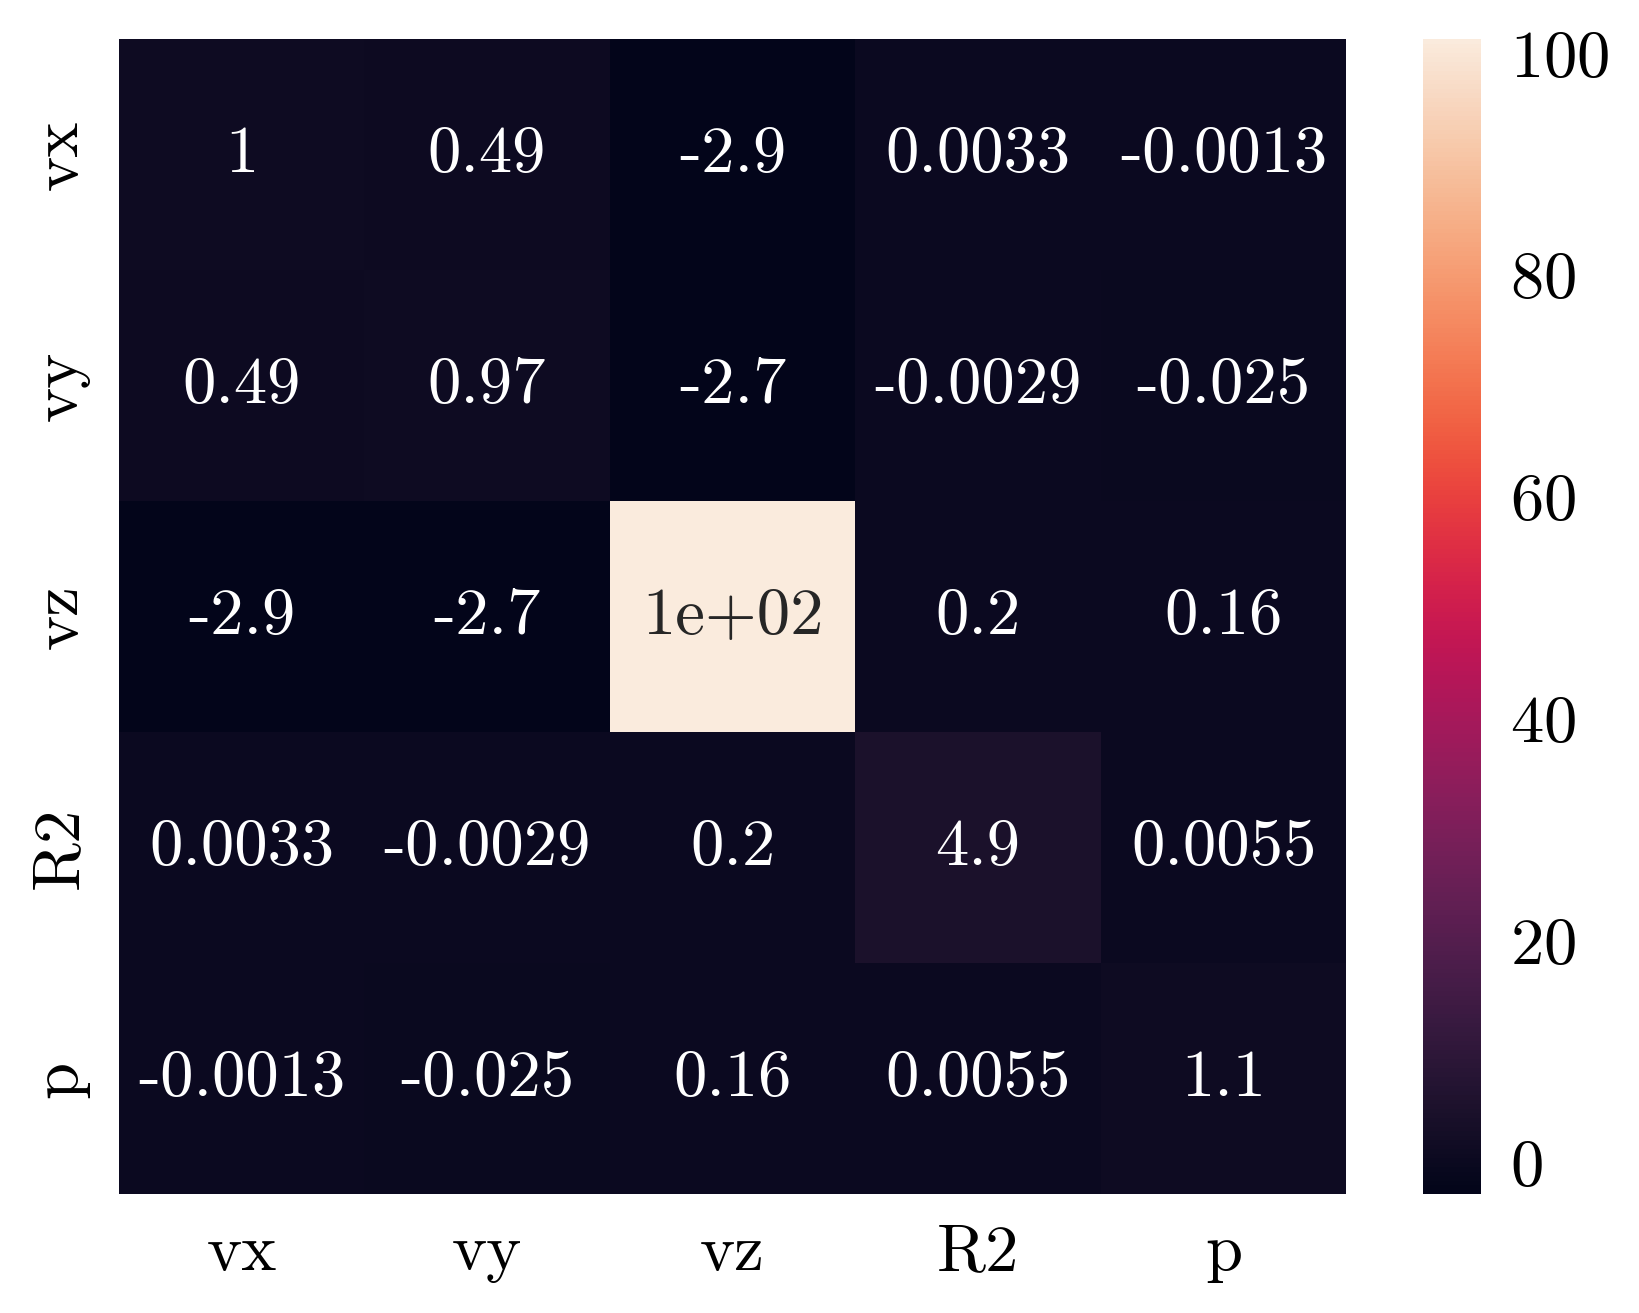

In [34]:
print(ps1_data.cov())
sns.heatmap(ps1_data.cov(), annot=True)
plt.show()

#### 2